In [1]:
import seaborn as sns

from util import *

linear coefs= [[0.50009091]] [3.00009091]
linear error= 1.1185497916336298


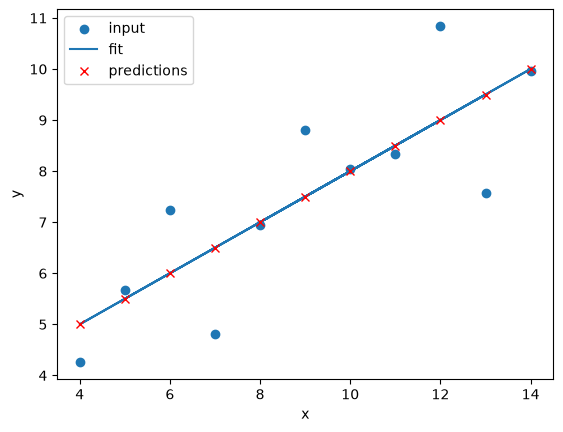

linear coefs= [[0.5]] [3.00090909]
linear error= 1.1191023557497446


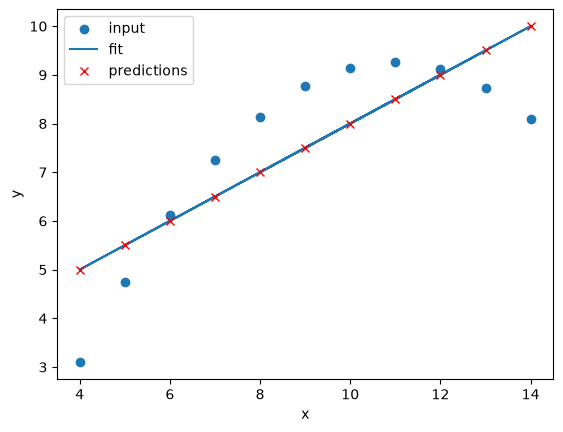

linear coefs= [[0.49972727]] [3.00245455]
linear error= 1.118285693623049


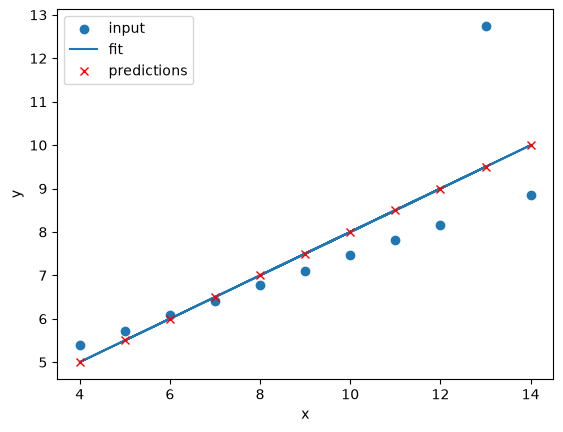

linear coefs= [[0.49990909]] [3.00172727]
linear error= 1.1177286221293936


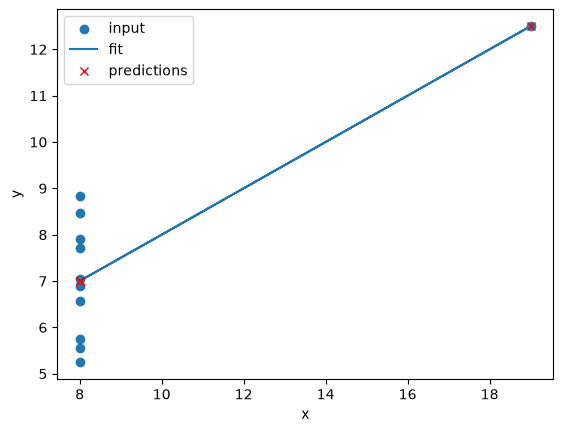

In [2]:
data = sns.load_dataset("anscombe")

for ansc_set in ["I", "II", "III", "IV"]:
    ansc_df = data[data["dataset"] == ansc_set]
    fit_predict_plot_linear(ansc_df.x, ansc_df.y)
    plt.show()

In [3]:
dataset = sns.load_dataset("penguins")
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


In [4]:
dataset.dropna(inplace=True)
dataset.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female
5,Adelie,Torgersen,39.3,20.6,190.0,3650.0,Male


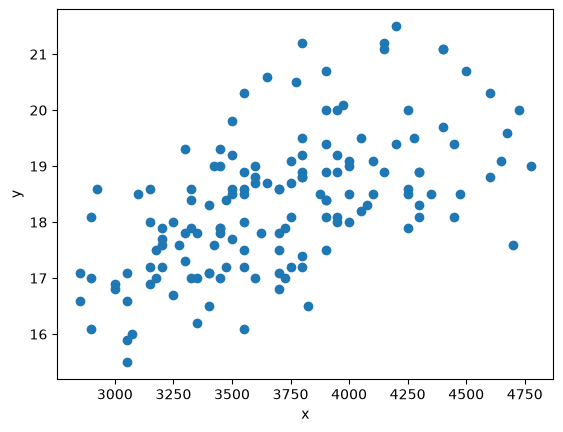

In [5]:
dataset_1 = dataset[:146]
plot_linear(dataset_1["body_mass_g"], dataset_1["bill_depth_mm"])

RMSE: 0.989750418206048


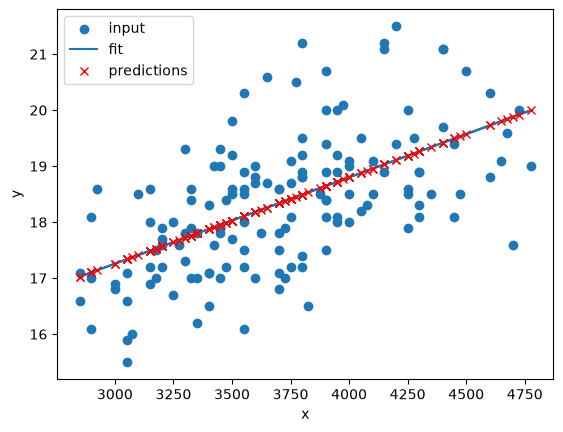

In [6]:
from sklearn.linear_model import LinearRegression

x_data, y_data = pre_process_linear(dataset_1["body_mass_g"], dataset_1["bill_depth_mm"])

model = LinearRegression()
lin_regress = model.fit(x_data, y_data)

predicted_data = lin_regress.predict(x_data)
error = math.sqrt(mean_squared_error(y_data, predicted_data))
print("RMSE:", error)

plot_linear_model(x_data, y_data, predicted_data)

RMSE: 3.395330944365877


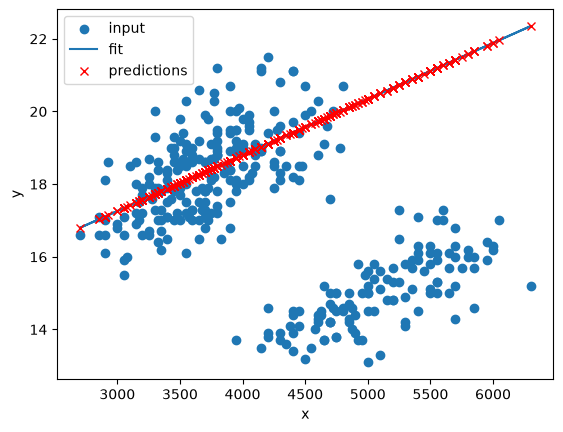

In [7]:
x_data, y_data = pre_process_linear(dataset["body_mass_g"], dataset["bill_depth_mm"])

predicted_data = lin_regress.predict(x_data)
error = math.sqrt(mean_squared_error(y_data, predicted_data))
print("RMSE:", error)

plot_linear_model(x_data, y_data, predicted_data)

In [8]:
X, y = get_penguin_classification_data()

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

<Axes: xlabel='bill_length_mm', ylabel='bill_depth_mm'>

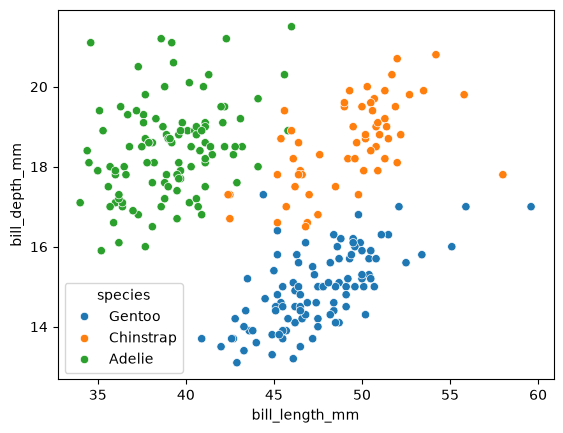

In [10]:
sns.scatterplot(X_train, x="bill_length_mm", y="bill_depth_mm", hue=y_train)

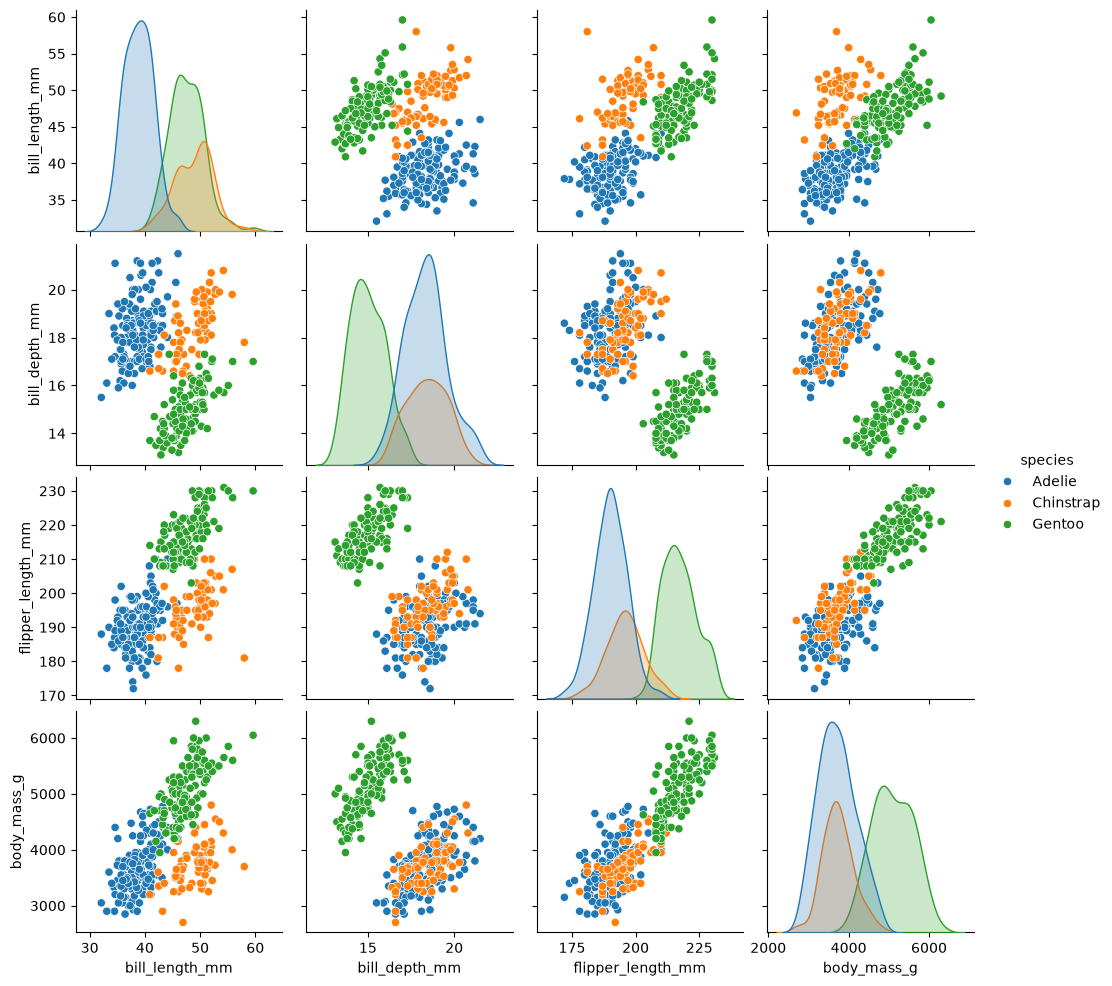

In [11]:
sns.pairplot(dataset, hue="species")

In [12]:
from sklearn.tree import DecisionTreeClassifier

clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train, y_train)

clf.predict(X_test)

array(['Adelie', 'Adelie', 'Gentoo', 'Adelie', 'Adelie', 'Adelie',
       'Chinstrap', 'Gentoo', 'Gentoo', 'Chinstrap', 'Gentoo', 'Adelie',
       'Adelie', 'Chinstrap', 'Adelie', 'Adelie', 'Gentoo', 'Adelie',
       'Chinstrap', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo',
       'Gentoo', 'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Adelie', 'Chinstrap', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Chinstrap', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie',
       'Gentoo', 'Adelie', 'Adelie', 'Adelie', 'Gentoo', 'Gentoo',
       'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Adelie', 'Gentoo',
       'Adelie', 'Chinstrap', 'Adelie', 'Gentoo', 'Adelie', 'Adelie',
       'Chinstrap'], dtype=object)

In [13]:
clf_score = clf.score(X_test, y_test)
print(clf_score)

0.9402985074626866


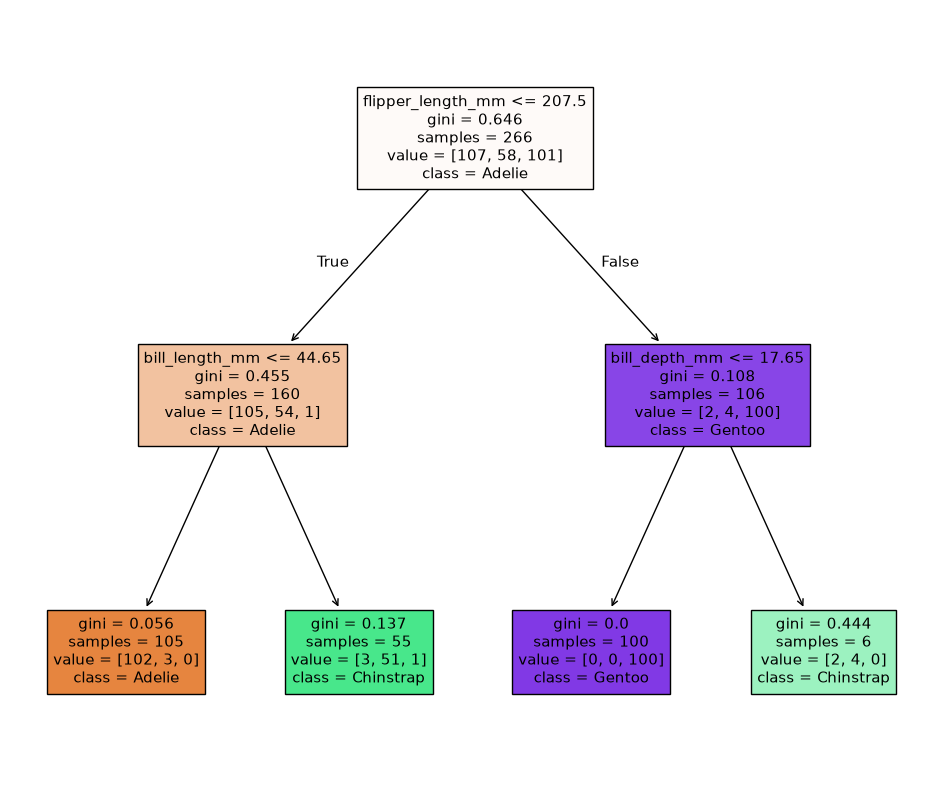

In [14]:
view_decision_tree_classifier(clf)

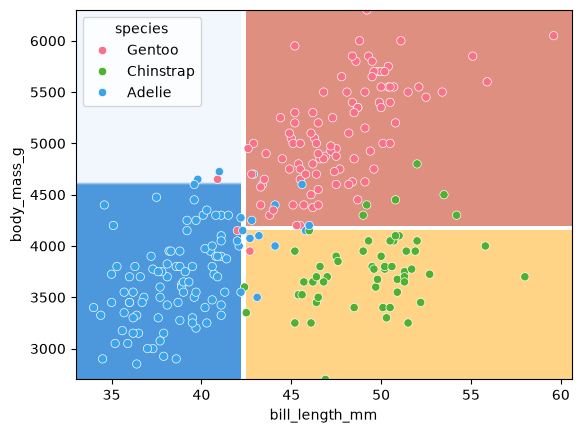

In [17]:
clf = DecisionTreeClassifier(max_depth=2)
clf.fit(X_train[["bill_length_mm", "body_mass_g"]], y_train)
plot_decision_tree_decision_boundaries(clf, X_train, y_train)

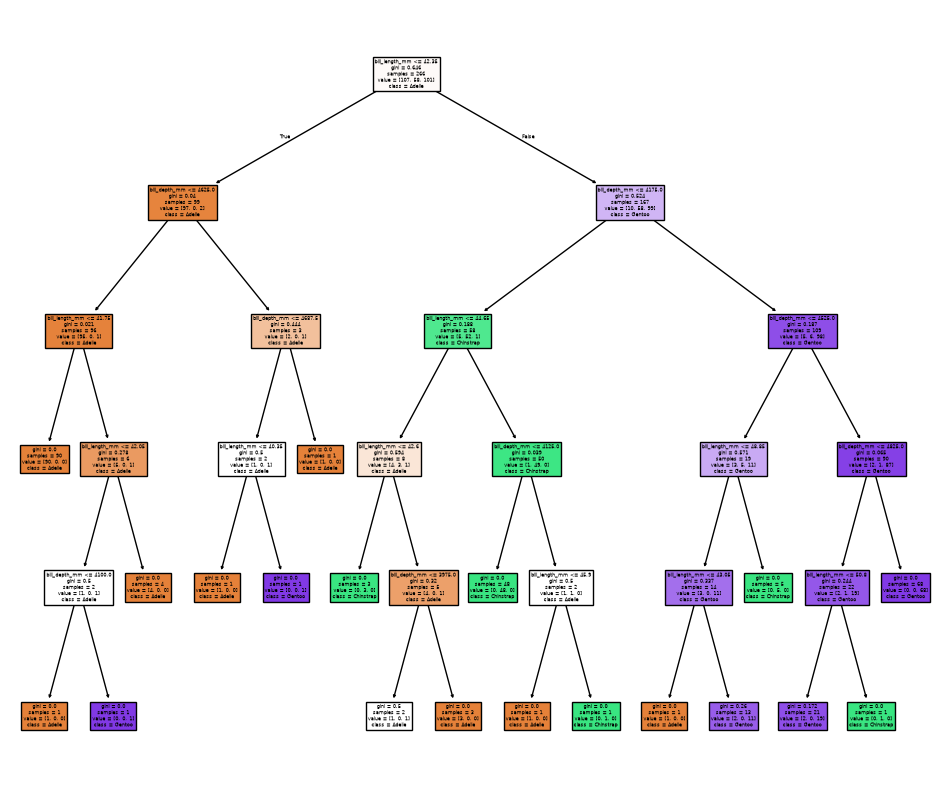

In [18]:
clf = DecisionTreeClassifier(max_depth=5)
clf.fit(X_train[["bill_length_mm", "body_mass_g"]], y_train)
view_decision_tree_classifier(clf)

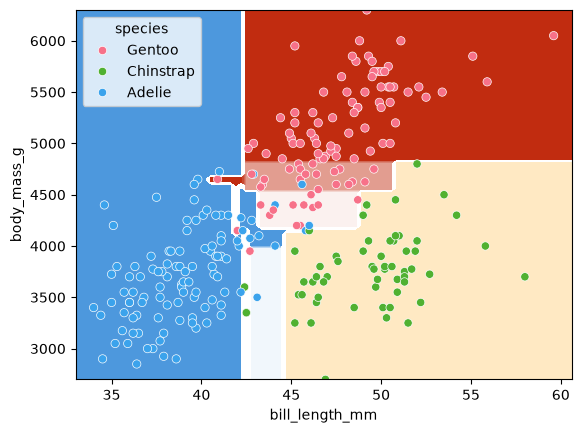

In [19]:
plot_decision_tree_decision_boundaries(clf, X_train, y_train)